# VeriNews AI — Milestone 2: DistilBERT Fine-Tuning (Colab/Kaggle GPU)

> **Important:** This notebook is designed for **GPU-accelerated environments only** (Google Colab T4/A100, Kaggle P100/T4).  
> The `train_distilbert.py` script will refuse to run full training on CPU.  
> For a local smoke test, see the README.

## Prerequisites
1. GPU runtime selected (Colab: Runtime → Change runtime type → T4 GPU)
2. `unified_dataset.csv` available — either from the repo or uploaded manually
3. (Optional) Google Drive mounted for saving checkpoints

## What this notebook does
1. Clones the VeriNews AI repository
2. Installs dependencies
3. Generates frozen train/val/test splits with provenance manifest
4. Runs token-length analysis to confirm `MAX_SEQ_LEN`
5. Runs full DistilBERT fine-tuning (3 epochs)
6. Evaluates on the frozen test split and the 60-example manual validation set
7. Saves the checkpoint to Google Drive

## Step 0 — Verify GPU

In [1]:
import torch
print(f'CUDA available : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU            : {torch.cuda.get_device_name(0)}')
    print(f'VRAM           : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
else:
    raise RuntimeError('No GPU detected. Change runtime to GPU before proceeding.')

CUDA available : True
GPU            : Tesla T4
VRAM           : 15.6 GB


## Step 1 — Clone repository

In [2]:
import os

REPO_URL = 'https://github.com/Karan-lab-collab/VeriNews-AI.git'
REPO_BRANCH = 'master'
REPO_DIR    = '/content/VeriNews-AI'

if not os.path.exists(REPO_DIR):
    !git clone --branch {REPO_BRANCH} {REPO_URL} {REPO_DIR}
else:
    !git -C {REPO_DIR} pull

os.chdir(f'{REPO_DIR}/backend')
print(f'Working directory: {os.getcwd()}')

Cloning into '/content/VeriNews-AI'...
remote: Enumerating objects: 119, done.
remote: Counting objects: 100% (119/119), done.
remote: Compressing objects: 100% (94/94), done.
remote: Total 119 (delta 13), reused 116 (delta 10), pack-reused 0 (from 0)
Receiving objects: 100% (119/119), 423.48 KiB | 10.59 MiB/s, done.
Resolving deltas: 100% (13/13), done.
Working directory: /content/VeriNews-AI/backend


## Step 2 — Install dependencies

In [3]:
!pip install -q -r requirements.txt
print('Dependencies installed.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.7/61.7 kB 2.5 MB/s eta 0:00:00
Dependencies installed.


## Step 3 — Upload dataset

The `datasets/` directory is excluded from git (large files).  
Upload or copy `unified_dataset.csv` to `backend/datasets/processed/` now.

In [4]:
import os
from pathlib import Path

DATASET_PATH = Path('datasets/processed/unified_dataset.csv')

if not DATASET_PATH.exists():
    # Option A: Upload from local machine
    from google.colab import files
    DATASET_PATH.parent.mkdir(parents=True, exist_ok=True)
    print('Upload unified_dataset.csv now:')
    uploaded = files.upload()
    for name, data in uploaded.items():
        DATASET_PATH.write_bytes(data)
    print(f'Saved to {DATASET_PATH}')

    # Option B: Copy from Google Drive (uncomment if preferred)
    # from google.colab import drive
    # drive.mount('/content/drive')
    # !cp '/content/drive/MyDrive/VeriNews/unified_dataset.csv' {DATASET_PATH}
else:
    print(f'Dataset already present: {DATASET_PATH} ({DATASET_PATH.stat().st_size/1e6:.1f} MB)')

Upload unified_dataset.csv now:


Saving unified_dataset.csv to unified_dataset.csv
Saved to datasets/processed/unified_dataset.csv


## Step 4 — Generate frozen splits + token-length analysis

In [5]:
!python train/transformer/dataset.py --prepare --analyze-lengths --sample-size 15000

[dataset] Loading unified dataset from /content/VeriNews-AI/backend/datasets/processed/unified_dataset.csv …
[dataset]   Rows before dedup: 79,154
[dataset]   Duplicates removed: 0
[dataset]   Rows after dedup: 79,154
[dataset]   Train : 63,323  {'REAL': 34482, 'FAKE': 28841}
[dataset]   Val   : 7,915  {'REAL': 4310, 'FAKE': 3605}
[dataset]   Test  : 7,916  {'REAL': 4311, 'FAKE': 3605}
[dataset]   Manifest saved → /content/VeriNews-AI/backend/datasets/processed/distilbert_v1/split_manifest.json

[dataset] Token-length analysis using 'distilbert-base-uncased' tokenizer …
          (sampling 15,000 articles from training split)
config.json: 100% 483/483 [00:00<00:00, 2.37MB/s]
tokenizer_config.json: 100% 48.0/48.0 [00:00<00:00, 313kB/s]
vocab.txt: 100% 232k/232k [00:00<00:00, 9.62MB/s]
tokenizer.json: 100% 466k/466k [00:00<00:00, 28.0MB/s]
[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (585 > 512). Running this sequence th

## Step 5 — Review token-length stats and confirm MAX_SEQ_LEN

Read the output above.  
Choose `MAX_SEQ_LEN` based on the p90/p95 percentiles and the truncation trade-off guide.  
Update the value below before running Step 6.

In [6]:
import json

stats_path = 'results/distilbert_v1/token_length_stats.json'
with open(stats_path) as f:
    stats = json.load(f)

print('Token-length statistics:')
for k, v in stats.items():
    if k != 'notes':
        print(f'  {k:<14}: {v}')

# ── SET THIS VALUE AFTER REVIEWING THE OUTPUT ABOVE ──────────────────────────
MAX_SEQ_LEN = 512  # ← update based on p90/p95 from Step 4 output
print(f'\nSelected MAX_SEQ_LEN: {MAX_SEQ_LEN}')
print('This value will be passed to train_distilbert.py --max-seq-len')

Token-length statistics:
  sample_size   : 15000
  mean          : 457.60286666666667
  median        : 413.0
  p75           : 578.25
  p90           : 826.0
  p95           : 998.0
  p99           : 1588.0800000000017
  max           : 9358
  min           : 4
  tokenizer     : distilbert-base-uncased

Selected MAX_SEQ_LEN: 512
This value will be passed to train_distilbert.py --max-seq-len


## Step 6 — Full training (GPU required)

In [7]:
!python train/transformer/train_distilbert.py \
    --max-seq-len {MAX_SEQ_LEN} \
    --epochs 3 \
    --batch-size 8 \
    --lr 2e-5 \
    --weight-decay 0.01

  VeriNews AI — Milestone 2: DistilBERT Fine-Tuning
[device] CUDA available — GPU : Tesla T4  (15.6 GB VRAM)

────────────────────────────────────────────────────────────
  Full training configuration
────────────────────────────────────────────────────────────
  Model checkpoint    : distilbert-base-uncased
  Max sequence length : 512 tokens
  Device              : cuda
  GPU                 : Tesla T4 (15.6 GB VRAM)
  Precision           : fp16 (mixed)
  Physical batch size : 8 (per device)
  Gradient accumulation: 2 steps
  Effective batch size : 16
  Learning rate       : 2e-05
  Weight decay        : 0.01
  Epochs              : 3
  Warmup ratio        : 0.06
  Best-model metric   : eval_f1
  Label mapping       : {0: 'FAKE', 1: 'REAL'}
────────────────────────────────────────────────────────────

[train] Loading frozen splits …
[train]   train  : 63,323 examples
[train]   val    : 7,915 examples

[train] Loading tokenizer: distilbert-base-uncased …
[train] Tokenising datasets …
[

## Step 7 — Evaluate

In [8]:
!python train/transformer/evaluate_distilbert.py \
    --checkpoint saved_models/distilbert_v1/best \
    --max-seq-len {MAX_SEQ_LEN}

[eval] Loading checkpoint from saved_models/distilbert_v1/best …
Loading weights: 100% 104/104 [00:00<00:00, 5189.49it/s]
[eval]   Device: cuda

[eval] Evaluating on FROZEN test split (/content/VeriNews-AI/backend/datasets/processed/distilbert_v1/test.csv) …

  Test split metrics (test):
    Accuracy  : 0.9946
    Precision : 0.9954
    Recall    : 0.9947
    F1        : 0.9950

  Inference latency (test, 7916 examples):
    Total    : 148.01s
    Per-sample: 18.70ms
    Device   : cuda
[eval]   Confusion matrix → /content/VeriNews-AI/backend/results/distilbert_v1/confusion_matrix.png

[eval] Running manual validation (same 60-example set as baseline) …
       /content/VeriNews-AI/backend/validation/validation.csv

  Overall manual validation accuracy: 85.0%

  Per-category accuracy:
  Category                Acc  (correct/total)
  Politics             [████████████████████] 100.0%  (5/5)
  Conspiracy           [████████████████████] 100.0%  (5/5)
  Business             [██████████████

## Step 8 — Save checkpoint to Google Drive

In [9]:
# Mount Drive if not already mounted
from google.colab import drive
drive.mount('/content/drive', force_remount=False)

import shutil, os
DRIVE_DEST = '/content/drive/MyDrive/VeriNews/distilbert_v1'
os.makedirs(DRIVE_DEST, exist_ok=True)

# Copy checkpoint
shutil.copytree('saved_models/distilbert_v1/best', f'{DRIVE_DEST}/best', dirs_exist_ok=True)
# Copy results
shutil.copytree('results/distilbert_v1', f'{DRIVE_DEST}/results', dirs_exist_ok=True)
# Copy split manifests
shutil.copytree('datasets/processed/distilbert_v1', f'{DRIVE_DEST}/splits', dirs_exist_ok=True)

print(f'Checkpoint and results saved to {DRIVE_DEST}')

Mounted at /content/drive
Checkpoint and results saved to /content/drive/MyDrive/VeriNews/distilbert_v1


## Step 9 — Display key results

=== Test Split Metrics ===
  smoke_test     : False
  n_examples     : 7916
  accuracy       : 0.9946
  precision      : 0.9954
  recall         : 0.9947
  f1             : 0.995

=== Manual Validation Report preview ===
# DistilBERT v1 — Manual Validation Report

> This report uses the **same 60-example validation set** used for the TF-IDF baseline.
> Results are directly comparable to `backend/results/manual_validation_report.md`.

## Overall Metrics

| Metric | Score |
|--------|-------|
| Accuracy  | 85.0% |
| Precision | 87.5% |
| Recall    | 89.7% |
| F1-Score  | 88.6% |

## Per-Category Accuracy

| Category | Accuracy | Correct / Total |
|----------|----------|-----------------|
| Politics | 100.0% | 5/5 |
| Conspiracy | 100.0% | 5/5 |

=== Confusion Matrix ===


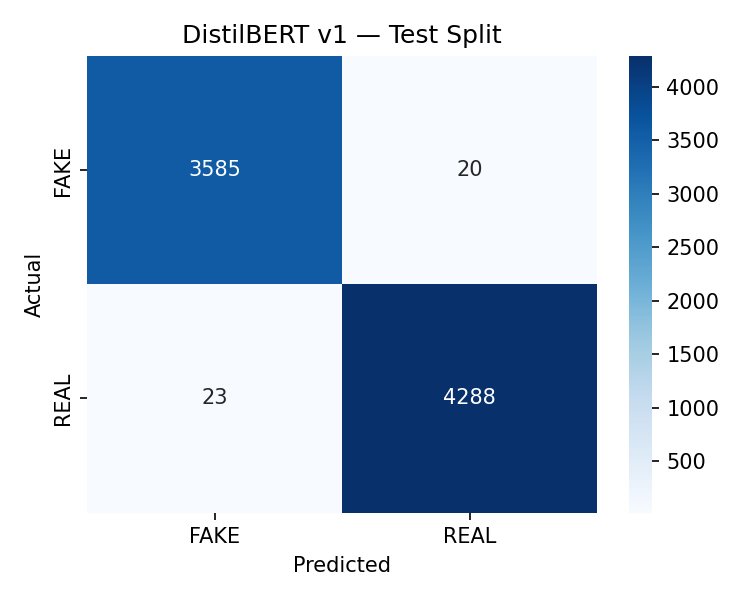

In [10]:
import json
from IPython.display import Image, display

# Test split metrics
with open('results/distilbert_v1/metrics.json') as f:
    metrics = json.load(f)
print('=== Test Split Metrics ===')
for k, v in metrics.items():
    if isinstance(v, (int, float)):
        print(f'  {k:<15}: {v}')

print()

# Manual validation metrics
print('=== Manual Validation Report preview ===')
with open('results/distilbert_v1/manual_validation_distilbert_report.md') as f:
    for i, line in enumerate(f):
        if i < 20:
            print(line, end='')

print()
print('=== Confusion Matrix ===')
display(Image('results/distilbert_v1/confusion_matrix.png'))

In [11]:
import os

print("=== MODEL FILES ===")
for root, dirs, files in os.walk("saved_models/distilbert_v1"):
    for file in files:
        path = os.path.join(root, file)
        print(f"{path} -> {os.path.getsize(path) / 1024**2:.2f} MB")

print("\n=== RESULT FILES ===")
for root, dirs, files in os.walk("results/distilbert_v1"):
    for file in files:
        path = os.path.join(root, file)
        print(f"{path} -> {os.path.getsize(path) / 1024**2:.2f} MB")

=== MODEL FILES ===
saved_models/distilbert_v1/best/model.safetensors -> 255.43 MB
saved_models/distilbert_v1/best/tokenizer_config.json -> 0.00 MB
saved_models/distilbert_v1/best/tokenizer.json -> 0.68 MB
saved_models/distilbert_v1/best/config.json -> 0.00 MB
saved_models/distilbert_v1/best/training_args.bin -> 0.00 MB
saved_models/distilbert_v1/best/checkpoint-11874/rng_state.pth -> 0.01 MB
saved_models/distilbert_v1/best/checkpoint-11874/model.safetensors -> 255.43 MB
saved_models/distilbert_v1/best/checkpoint-11874/scaler.pt -> 0.00 MB
saved_models/distilbert_v1/best/checkpoint-11874/trainer_state.json -> 0.02 MB
saved_models/distilbert_v1/best/checkpoint-11874/scheduler.pt -> 0.00 MB
saved_models/distilbert_v1/best/checkpoint-11874/config.json -> 0.00 MB
saved_models/distilbert_v1/best/checkpoint-11874/training_args.bin -> 0.00 MB
saved_models/distilbert_v1/best/checkpoint-11874/optimizer.pt -> 510.91 MB
saved_models/distilbert_v1/best/checkpoint-7916/rng_state.pth -> 0.01 MB
save

In [12]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [13]:
import shutil
from pathlib import Path

source = Path("saved_models/distilbert_v1/best")
destination = Path("/content/drive/MyDrive/VeriNews-AI/distilbert_v1_best")

destination.parent.mkdir(parents=True, exist_ok=True)

shutil.copytree(
    source,
    destination,
    dirs_exist_ok=True
)

print("Saved final DistilBERT model to:")
print(destination)

Saved final DistilBERT model to:
/content/drive/MyDrive/VeriNews-AI/distilbert_v1_best


In [14]:
import shutil

shutil.make_archive(
    "distilbert_v1_results",
    "zip",
    "results/distilbert_v1"
)

print("Created distilbert_v1_results.zip")

Created distilbert_v1_results.zip


In [15]:
import os

print(os.getcwd())
print(os.path.abspath("distilbert_v1_results.zip"))
print(os.path.exists("distilbert_v1_results.zip"))

/content/VeriNews-AI/backend
/content/VeriNews-AI/backend/distilbert_v1_results.zip
True


In [16]:
!python train/transformer/predict_distilbert.py \
    --checkpoint saved_models/distilbert_v1/best \
    --max-seq-len 512 \
    --text "Scientists at NASA announced today that the James Webb Space Telescope has discovered new details about a distant exoplanet's atmosphere after months of observation."

Loading weights: 100% 104/104 [00:00<00:00, 6232.96it/s]

────────────────────────────────────────────────────
  Prediction  : FAKE
  Confidence  : 99.99%
  [█████████████████████████████░]
  P(FAKE)     : 99.99%
  P(REAL)     : 0.01%
────────────────────────────────────────────────────
